# Учебный проект: Изучение рынка заведений общественного питания Москвы

- Автор: Сергиенко Роман

### Цели и задачи проекта

**Цель**: провести исследовательский анализ рынка общественного питания Москвы, чтобы предложить инвесторам вараинт подходящего места для открытия своего заведения.

**Задачи**:
1. Загрузить данные и познакомится с ними.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных.
4. Сформулировать выводы по проведённому анализу.

### Описание данных

**Датасет `datasets/rest_info.csv`**:
- `id` - идентификатор заведения;
- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение;
- `category` — категория заведения;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах;
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым;
- `seats` — количество посадочных мест.

**Датасет `datasets/rest_price.csv`**:
- `id` - идентификатор заведения;
- `price` — категория цен в заведении;
- `avg_bill` — средняя стоимость заказа;
- `middle_avg_bill` — число с оценкой среднего чека;
- `middle_coffee_cup` — число с оценкой одной чашки капучино.



### Содержимое проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных
4. Итоговый вывод и рекомендации.

---

## 1. Загрузка данных и знакомство с ними

Начнем с загрузки библиотек и данных о заведениях общественного питания Москвы датасетов `datasets/rest_info.csv` и `datasets/rest_price.csv`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `rest_df` и `price_df`.

In [ ]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Импортируем библиотеку numpy для работы с числовыми данными,
# математическими операциями и обработкой пропущенных значений
import numpy as np

# Устанавливаем библиотеку phik с помощью кода
!pip install phik

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix



In [ ]:
# Выгружаем данные в датафреймы rest_df и price_df
rest_df = pd.read_csv('/datasets/rest_info.csv')
price_df = pd.read_csv('/datasets/rest_price.csv')



Познакомимся с данными датасета `datasets/rest_info.csv` — выведем первые сторки методом head() и общую информацию о датафрейме с помощью метода info():

In [ ]:
# Выводим первые строки датафрейма rest_df
rest_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [ ]:
# Выводим информацию о датафрейме rest_df
rest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Датасет `datasets/rest_info.csv` содержит 8406 строк и 9 столбцов, в которых представлена информация о заведениях общественного питания Москвы.

После первичного знакомства с данными можно сделать следующие выводы:
- Названия столбцов имеют вид snake case, что является стандартом для работы с pandas.
- Данные в столбцах представлены типом `object`, `int64` и `float64`, и они в целом соответствуют содержимому. Единственное исключение — столбец `chain`: он хранит информацию о том, является ли заведение сетевым или нет (соответственно, значения 1 или 0). Этот столбец можно преобразовать к булевому типу данных.
- Пропуски содержатся в столце `hours`, который содержит ифмормацио о днях и времени работы заведения, и столбце `seats` c информацией о количестве посадочных мест. Однако стоит проверить другие столбцы на наличие значений-индикаторов, которые будут говорить об отсутствии данных.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Далее познакомимся с данными датасета `datasets/rest_price.csv`.

Выведем первые сторки методом head() и общую информацию о датафрейме с помощью метода info():

In [ ]:
# Выводим первые строки датафрейма price_df
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [ ]:
# Выводим информацию о датафрейме price_df
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датасет `datasets/rest_price.csv` содержит 4058 строк и 5 столбцов, в которых представлена информация о ценах в заведениях общественного питания Москвы. Заметим, что количество строк меньше, чем в датасете `datasets/rest_info.csv`. Это означает, что информация о ценах есть не для всех заведений.

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов имеют вид snake case.
- Данные в столбцах представлены типами object и float64 и они соответствуют содержимому этих столбцов.
- Пропуски содержатся во всех столбцах, кроме `id`: `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup`. Самое большое количество пропусков содержит поле `middle_coffee_cup` с информацией о стоимости чашки капучино.
- Значения в столбцах соответствуют своему описанию.

---

### Промежуточный вывод



Были предоставлены два связанных датасета о заведениях общественного питания Москвы.
- `datasets/rest_price.csv`: 8406 записей о заведениях, 9 столбцов.
- `datasets/rest_price.csv`: 4058 записей о ценах, 5 столбцов.
Информация о ценах есть только для примерно половины заведений (4058 из 8406). При объединеии датафреймов стоит сохранить все строки датафрейма rest_df, чтобы не потерять значительную часть информации о заведениям общепита Москвы.

Данные в целом соответствуют описанию. В обоих датасетах названия столбцов имеют вид snake case, что является стандартом для работы.

В общей сложности пропуски содержат 6 поля в двух датасетах: `hours`, `seats`, `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup`. Наибольшее количество в столбце в столбце `seats` и `middle_coffee_cup`. Возможно, информацию о количестве мест в заведении (`seats`) просто отсутствует. Информация о стоимости чашки капучино должна быть заполнена только для значений из столбца `avg_bill`, начинающихся с подстроки «Цена одной чашки капучино». На следующем этапе анализа стоит проверить другие столбцы на наличие значений-индикаторов, которые будут указывать на отсутствие данных.

Типы данных указаны в целом верно. Можно преобразовать столбец `chain` к булевому типу данных: он хранит информацию о том, является ли заведение сетевым или нет — значения 1 или 0, соответственно. Для опитимизации также можно понизить разрядность числовых данных `float64` с 64 до 32 в столбцах `rating`, `seats`, `middle_avg_bill`, `middle_coffee_cup`.

### Подготовка единого датафрейма

Объединим данные датафреймов rest_df и price_df в один так, чтобы сохранить все строки из датафрейма rest_df.

In [ ]:
# Объединим датафреймы rest_df и price_df с помощью метода merge(), используя общий для них столбец id.
# Будем использовать тип соединения left, чтобы сохранить все строки из левого датафрейма датафрейм.
df = rest_df.merge(price_df, on='id', how='left')

In [ ]:
# Для проверки результата выведем на экран первые строки объединенного датафрейма df
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [ ]:
# Выведем информацию о датафрейме df и размер датафрейма
df.info()

print()
print('Размер датафрейма:')
display(len(df))

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB

Размер датафрейма:


8406

In [ ]:
# Создаем копию датафрейма до преобразования для возможности проверить сделанные изменения после предобработки
temp = df.copy()

После объединения датафреймов переходим к следующему этапу анализа данных.

In [ ]:
# Создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
temp = df.copy()
len(temp)

8406

## 2. Предобработка данных


Преобразуем столбец `chain` к булевому типу данных: он хранит информацию о том, является ли заведение сетевым или нет (значения 1 или 0).<br>
Также понизим разрядность числовых данных с 64 до 32 в столбцах `rating`, `seats`, `middle_avg_bill`, `middle_coffee_cup` с типом данных `float64`.

In [ ]:
# Преобразуем целочисленный тип данных в столбце chain к булевому
df['chain'] = df['chain'].astype(bool)

# Понизим разрядность вещественных числовых данных float64 в столбцах seats, middle_avg_bill, middle_coffee_cup
# Для этого используем цикл for

for column in ['rating', 'seats', 'middle_avg_bill', 'middle_coffee_cup']:
    df[column] = pd.to_numeric(df[column], downcast='float')

In [ ]:
# Проверяем типы данных в датафрейме df  после оптимизации с помощью атрибута dtypes
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float32
chain                   bool
seats                float32
price                 object
avg_bill              object
middle_avg_bill      float32
middle_coffee_cup    float32
dtype: object

Целочисленный тип данных в столбце chain был успешно преобразован в тип `bool`. В столбцах `rating`, `seats`, `middle_avg_bill`, `middle_coffee_cup` с типом данных `float64` понизили разрядность с 64 до 32.

При первичном знакомстве с данными мы обнаружили пропуски в обоих датасетах. Перейдем к подсчёту  количества пропусков в каждом столбце датафрейма в абсолютных и относительных значениях. Для этого создадим функцию, которая отобразит все необходимые значения.

In [ ]:
# Создадим функцию, которая отобразит статистику по количеству и доле пропусков в датафрейме df
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    Параметры:   tmp0 (pd.DataFrame): Исходный DataFrame для анализа
    Возвращает:  Styler или строку: Объект Styler с подсветкой или сообщение об отсутствии пропусков
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean().round(4)
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    return missing_stats.style.background_gradient(cmap='coolwarm') if not missing_stats.empty else "Пропусков в данных нет"
show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
hours,536,0.063800
seats,3611,0.429600
price,5091,0.605600
avg_bill,4590,0.546000
middle_avg_bill,5257,0.625400
middle_coffee_cup,7871,0.936400



</font><font color='Black'> В датафрейме `df` обнаружены пропуски в следующих столбцах:
- 7871 пропуск в столбце `middle_coffee_cup` — это 93% данных;
- 5257 пропусков в столбце `middle_avg_bill` — 62% данных;
- 5091 пропуск в столбце `price` — 60% данных;
- 4590 пропусков в столбце `avg_bill` — 54% данных;
- 3611 пропусков в столбце `seats` — 43% данных;
- 536 пропусков в столбце `hours` — 6% данных.
<br>

**Возможные причины** <br>
Пропуски в столбцах `price` и `seats` могут быть связаны: <br>
- Информация категории цены заведения и количестве посадочных мест отсутствует в источниках данных — сервисах «Яндекс Карты» и «Яндекс Бизнес». Сведения в эти сервисах добавляют пользователи или они были получены из открытых источников, и, возможно, на момент сбора данных (лето 2022 года) эта информация была доступна не для всех заведений. Особенно это может касаться непопулярных заведений — информацию о них с меньшей вероятностью могут добавить пользователи и с меньшей вероятностью ее можно найти в интернете. В целом этот тип пропусков можно отнести к типу MNAR (Missing Not At Random) — пропуски не случайны и зависят от ненаблюдаемых факторов.<br>
- При обработке данных произошёл технический сбой. Этот тип пропусков можно отнести к типу MCAR — пропуски совершенно случаены и не зависят ни от чего.<br>
- Пропуски связаны с данными из других столбцов. Например, пропуски могут встречаться только для определенных типов заведений или только для определенных районов. Стоит это проверить на этом этапе и исключить возможность неполноты данных для отдельных категорий. Могут быть и другие варинаты того, как другие признаки могут влиять на появления пропусков. Этот тип пропусков можно отнести к типу MAR — причину пропусков можно объяснить другими наблюдаемыми данными. <br>
Оставим пропуски в столбце `seats`.

Пропуски в столбцах `avg_bill`, `middle_avg_bill`, `middle_coffee_cup` связаны друг с другом. Число с оценкой среднего чека, указанное в столбце `middle_avg_bill`, есть только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт». Число с оценкой одной чашки капучино в столбце `middle_coffee_cup` указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Цена одной чашки капучино». Соответственно, значения в столбцах `middle_avg_bill` и  `middle_coffee_cup` зависят от значений в `avg_bill`. Поэтому большее количество пропусков мы обнаруживаем в столбцах `middle_coffee_cup` (93%) и `middle_avg_bill` (62%) и еще меньшее в `avg_bill` (54%). В целом все данные пропуски можно отнести к типу MAR — причину пропусков можно объяснить другими наблюдаемыми данными. Однако пропуски в столбце `avg_bill` скорее относится к типу MNAR — пропуски не случайны и зависят от ненаблюдаемых факторов.
Учитывая характер пропусков в этих столбцах, оставим их как есть.
<br>

Пропуски в столбце `hours` могут быть связаны: <br>
- Технническим сбоем при обработке данных (тип MCAR).
- Отсутствием данных в источниках (тип MNAR).<br>


Далее выполним следующие действия:
- проверим встречаются ли в столбцах `district`, `category`, `chain`,`rating` значения-индикаторы, которые можно рассматривать как пропуски




Проверим, встречаются ли в данных значения-индикаторы, которые можно рассматривать как пропуски. Рассмотрим ключевые столбцы для дальнейшего анализа: адмистративный район, категория заведения и является ли заведение сетевым или нет, рейтинг заведения.

In [ ]:
# Проверяем уникальные значения в столбцах
for column in ['district', 'category', 'chain','rating']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique())
    print()

Уникальные значения в столбце district:
['Восточный административный округ' 'Западный административный округ'
 'Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Центральный административный округ'
 'Юго-Восточный административный округ'
 'Юго-Западный административный округ' 'Южный административный округ']

Уникальные значения в столбце category:
['бар,паб' 'булочная' 'быстрое питание' 'кафе' 'кофейня' 'пиццерия'
 'ресторан' 'столовая']

Уникальные значения в столбце chain:
[False  True]

Уникальные значения в столбце rating:
[1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7
 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5
 4.6 4.7 4.8 4.9 5. ]



Значений-индикаторов в указанных столбцах не обнаружено. Все значения выглядят корректными.

Переходим к проверке данных на явные и неявные дубликаты. Начнем с полных дубликатов.

In [ ]:
# Проверяем полные дубликаты в датафрейме df
df.duplicated().sum()

0

Полных дубликатов не обнаружено. Теперь перейдем к неявным дубликатам. Прежде всего, проверим значения по `id` заведений: они должны быть уникальными.

In [ ]:
# Проверяем неявные дубликаты по id заведения
df.duplicated(subset='id').sum()

0

Каждая строка соответствует уникальному заведению.
<br>
Далее рассмотрим столбец `name` с названиями заведений. В датасете присутствуют сетевые заведения, поэтому ожидаемо, что одно и то же заведение может встречаться в разных локациях. Однако для поиска дубликатов в названиях необходимо учитывать, что названия могут быть написаны по-разному. Поэтому стоит провести нормализацию текстовых данных в столбце `name`, чтобы унифицировать формат названий и устранить различия в написании. После нормализации можно будет определить, сколько раз в столбце `name` повторяется значение, относящееся к одному заведению.

Сначала рассмотрим уникальные значения в столбце `name`, проведем нормализацию данных и затем определим количество неявных дубликатов.

In [ ]:
# Исследуем уникальные значения в столбце 'name'. Дополнительно сортируем список.
sorted(df['name'].unique())

['#КешбэкКафе',
 '+39 Pizzeria Mozzarella bar',
 '1 Этаж',
 '1-я Креветочная',
 '10 Идеальных Пицц',
 '1001 Ночь',
 '100ловая',
 '100лоффка',
 '13',
 '13 Chef doner',
 '15 Kitchen+Bar',
 '15-й Шар',
 '16 Июня',
 '16 Тонн',
 '18 Грамм',
 '1901 Comfort Food Zone',
 '1у',
 '2 Типа',
 '2-й Этаж',
 '2046',
 '21 Век',
 '22 Акра Кофе&Хлеб',
 '2U-Ту-Ю',
 '3 Ступени',
 '351 Bar',
 '4 Сезона',
 '4.2. Bar',
 '4/1 Restaurant',
 '42 Coffee Shop',
 '47',
 '495',
 '4friends Coffee',
 '4tuna Cafe&Grill',
 '5 Stars Coffee',
 '55.709201, 37.392257',
 '6 Am Bread Kitchen',
 '6 Рукопожатий',
 '69 раков',
 '7 Сэндвичей',
 '7 элемент',
 '7/12',
 '8 Oz',
 '8 Вафель',
 '8 Зёрен',
 '8 Пончиков',
 '800°с Contemporary Steak',
 '8bit Pizza',
 '9 Bar Coffe',
 '9 Bar Coffee',
 '9 Зёрен',
 'A-cafe',
 'ABC Coffee Roasters',
 'ABC coffee roasters',
 'Acai Family',
 'Accent',
 "Adam's Chicken",
 'Adria Mare',
 'Ahava',
 'Air Coffee',
 'Al Halal',
 'Al33 Пиццерия бар Боттега',
 'All Day',
 'Alma',
 'Alternative coffee',

In [ ]:
# Проверим количество дубликатов в столбце 'name' до нормализации и сохраним его в переменную name_before_norm
print('Количество дубликатов в столбце "name" до нормализации:')
name_before_norm = df.duplicated(subset='name').sum()
print(name_before_norm)

Количество дубликатов в столбце "name" до нормализации:
2792


В датасете есть 2792 строки, в которых значение в столбце `name` повторяется. Это ожидаемо, учитывая, что в датасете присутствуют сетевые заведения — одно и то же заведение может встречаться в разных локациях. <br>

Анализ уникальных значений в столбце `name` показал, что встречаются разные случаи когда одно и тоже названия заведения написано по-разному. Вот некоторые примеры, которые удалось обнаружить: `Corner cafe & kitchen` и `Corner cafe&kitchen`, `IL Pizzaiolo` и `IL pizzaiolo`, `It's СоТ - Кофейня` и `It's СоТ-Кофейня`, `Deli2Go` и `Deli2go` и т.д.

<br>
Выведем эти примеры и проверим, являются ли эти строки дубликатами.

In [ ]:
# Выведем строки по названиям заведений в столбце name
display(df.loc[(df['name'] == 'Corner cafe & kitchen') |
             (df['name'] == 'Corner cafe&kitchen') |
             (df['name'] == 'IL Pizzaiolo') |
             (df['name'] == 'IL pizzaiolo') |
             (df['name'] == "It's СоТ - Кофейня") |
             (df['name'] == "It's СоТ-Кофейня") |
             (df['name'] == 'Deli2Go') |
             (df['name'] == 'Deli2go')])

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
1249,d7870bb0c12c44e1822d01432cbb8db1,Deli2Go,быстрое питание,"Москва, улица Маршала Прошлякова, 11",Северо-Западный административный округ,NaN,3.8,True,NaN,NaN,NaN,NaN,NaN
1654,dc9bd713a79542678915321140c1334b,Corner cafe & kitchen,ресторан,"Москва, Новодмитровская улица, 2, корп. 4",Северо-Восточный административный округ,"ежедневно, 12:00–23:00",4.4,False,38.0,средние,Средний счёт:700–1200 ₽,950.0,NaN
1898,2e6cda4a9b874feda21ca594ea4d8ac7,It's СоТ - Кофейня,кофейня,"Москва, Бумажный проезд, 14, стр. 1",Северный административный округ,пн-пт 08:00–19:00,4.4,False,NaN,средние,Цена чашки капучино:90–240 ₽,NaN,165.0
1913,1b002493259a4f798bb68f2feb1fa244,It's СоТ-Кофейня,кофейня,"Москва, 1-я улица Ямского Поля, 17к12",Северный административный округ,пн-пт 08:00–19:00,4.4,False,NaN,NaN,NaN,NaN,NaN
3915,86bc48cbba9943f3b9bc48c169f208b7,Corner cafe&kitchen,ресторан,"Москва, Композиторская улица, вл17/5",Центральный административный округ,"пн-чт 12:00–23:00; пт,сб 12:00–00:00; вс 12:00...",4.7,False,NaN,выше среднего,Средний счёт:1000–1500 ₽,1250.0,NaN
3995,6da506fd42884357ac86bf6bb6c7b940,IL Pizzaiolo,пиццерия,"Москва, улица Арбат, 31",Центральный административный округ,"пн-чт 10:00–23:00; пт,сб 10:00–00:00; вс 10:00...",4.5,False,90.0,высокие,Средний счёт:1500–2000 ₽,1750.0,NaN
4778,20f347b1fe474189b205dc62a40f3bf9,IL pizzaiolo,ресторан,"Москва, Никольская улица, 11-13с1",Центральный административный округ,"пн-чт 10:00–23:00; пт,сб 10:00–00:00; вс 10:00...",4.4,False,NaN,выше среднего,Средний счёт:1200–1500 ₽,1350.0,NaN
5528,d21f30ec99374fe288d32586d2c70b1d,Deli2go,кафе,"Москва, Юрьевский переулок, 17, стр. 1",Юго-Восточный административный округ,NaN,4.1,True,NaN,NaN,NaN,NaN,NaN
7734,94df484fa07e497d80cd7a64d97d3ad6,Deli2go,кафе,"Москва, Новоясеневский проспект, вл4Ас1",Юго-Западный административный округ,NaN,4.0,True,NaN,NaN,NaN,NaN,NaN


Строки с повторяющимися названиями заведений не являются дубликатами: у них разные адреса и другие характеристики. Можно сделать допущение о том, что и в остальных случаях истинных дубликатов мы не обнаружим. Заметим также, что не везде заведения отмечены как сетевые в поле `chain` хотя они таковыми являются: `Corner cafe & kitchen`, `IL Pizzaiolo`, `It's СоТ - Кофейня`. Отметим, что в первоначальном описании датасета было указано, что для маленьких сетей могут встречаться ошибки. Что и было обнаружено.<br>
<br>
Вернемся к проблеме различного способа написания одних и техже названий. Некоторые разночтения в написания можно исправить только в ручном режиме, поскольку автоматическая замена может затронуть названия, которые изначально записаны верно (например, замена '&' на ' & ' изменит изначально корректное название заведения `G&M` на `G & M`). Точечная корректировна названий достаточно трудоёмкая задача и в контексте нашего проекта ее можно опустить. Для нормализации данных в этом текстовом столбце мы сначала приведём все названия к нижнему регистру с помощью метода lower(), чтобы их унифицировать, а затем преобразуем первый символ каждого слова в верхний регистр, используя метод title(). Это позволит быстро привести корректировку таких названий, как `IL Pizzaiolo` и `IL pizzaiolo`, `Deli2Go` и `Deli2go` (но не затронит случаи `It's СоТ - Кофейня` и `It's СоТ-Кофейня`).

In [ ]:
# Приведем все названия к нижнему регистру с помощью метода lower(),
# затем методом str.title() преобразуем первый символ каждого слова в верхний регистр
# df['name'] = df['name'].str.lower()
# df['name'] = df['name'].str.title()

In [ ]:
# Приведем все названия к нижнему регистру с помощью метода lower(),
# затем методом str.title() преобразуем первый символ каждого слова в верхний регистр.
# Еще удалим конечные проблеы методом str.strip()
df['name'] = df['name'].str.lower()
df['name'] = df['name'].str.title()
df['name'] = df['name'].str.strip()

In [ ]:
# Выведем уникальные значения в столбце 'name' после нормализации.
sorted(df['name'].unique())

['#Кешбэккафе',
 '+39 Pizzeria Mozzarella Bar',
 '1 Этаж',
 '1-Я Креветочная',
 '10 Идеальных Пицц',
 '1001 Ночь',
 '100Ловая',
 '100Лоффка',
 '13',
 '13 Chef Doner',
 '15 Kitchen+Bar',
 '15-Й Шар',
 '16 Июня',
 '16 Тонн',
 '18 Грамм',
 '1901 Comfort Food Zone',
 '1У',
 '2 Типа',
 '2-Й Этаж',
 '2046',
 '21 Век',
 '22 Акра Кофе&Хлеб',
 '2U-Ту-Ю',
 '3 Ступени',
 '351 Bar',
 '4 Сезона',
 '4.2. Bar',
 '4/1 Restaurant',
 '42 Coffee Shop',
 '47',
 '495',
 '4Friends Coffee',
 '4Tuna Cafe&Grill',
 '5 Stars Coffee',
 '55.709201, 37.392257',
 '6 Am Bread Kitchen',
 '6 Рукопожатий',
 '69 Раков',
 '7 Сэндвичей',
 '7 Элемент',
 '7/12',
 '8 Oz',
 '8 Вафель',
 '8 Зёрен',
 '8 Пончиков',
 '800°С Contemporary Steak',
 '8Bit Pizza',
 '9 Bar Coffe',
 '9 Bar Coffee',
 '9 Зёрен',
 'A-Cafe',
 'Abc Coffee Roasters',
 'Acai Family',
 'Accent',
 "Adam'S Chicken",
 'Adria Mare',
 'Ahava',
 'Air Coffee',
 'Al Halal',
 'Al33 Пиццерия Бар Боттега',
 'All Day',
 'Alma',
 'Alternative Coffee',
 'Aly’S Poke',
 'Amande

In [ ]:
# Проверим количество дубликатов в столбце 'name' после нормализации
print('Количество дубликатов в столбце "name" после нормализации:')
print(df.duplicated(subset='name').sum())
print()
print('Количество названий заведений, которые удалось привести к единому виду:')
print(df.duplicated(subset='name').sum() - name_before_norm)

Количество дубликатов в столбце "name" после нормализации:
2894

Количество названий заведений, которые удалось привести к единому виду:
102


Мы провели частичную нормализацию текстовых значений в столбце `name`, которая позволила привести к единому виду 102 названия.
Рассмотрим еще один столбец, который содержит текстовые данные — `address`.

In [ ]:
# Исследуем уникальные значения в столбце 'address', отсортивровав их для удобства
sorted(df['address'].unique())

['Москва, 1-й Автозаводский проезд, 5',
 'Москва, 1-й Балтийский переулок, 3/25',
 'Москва, 1-й Варшавский проезд, 1Ас9',
 'Москва, 1-й Вешняковский проезд, 15',
 'Москва, 1-й Волоколамский проезд, 10',
 'Москва, 1-й Волоколамский проезд, 10, стр. 1',
 'Москва, 1-й Голутвинский переулок, 6',
 'Москва, 1-й Грайвороновский проезд, 2А',
 'Москва, 1-й Дербеневский переулок, 5',
 'Москва, 1-й Дорожный проезд, 1, корп. 2',
 'Москва, 1-й Дорожный проезд, 1к2',
 'Москва, 1-й Дорожный проезд, 4, стр. 1',
 'Москва, 1-й Земельный переулок, 1',
 'Москва, 1-й Капотнинский проезд, 12, стр. 1',
 'Москва, 1-й Кирпичный переулок, 2, стр. 2',
 'Москва, 1-й Колобовский переулок, 17с1',
 'Москва, 1-й Котляковский переулок, 3',
 'Москва, 1-й Красногвардейский проезд, 15',
 'Москва, 1-й Красногвардейский проезд, 19',
 'Москва, 1-й Красногвардейский проезд, 21с2',
 'Москва, 1-й Красногвардейский проезд, 22, стр. 2',
 'Москва, 1-й Курьяновский проезд, 1с1/20',
 'Москва, 1-й Лучевой просек, 1',
 'Москва, 1-й Л

В написании адресов заведений в столбце `address` по-разному указывается корпус и строение: можно встретить сокращение до первой буквы ("к" и "с"), сокращение "корп" и "стр". В остальном существенных разочтений нет. <br>

Теперь проверим значения по `name` и `address` вместе на наличие неявных дубликатов.

In [ ]:
# Проверяем неявные дубликаты одновременно по name и address
df[df.duplicated(subset=['name', 'address'])]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
1511,a69f018d5c064873a3b491b0121bc1b4,More Poke,ресторан,"Москва, Волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,True,188.0,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,Раковарня Клешни И Хвосты,"бар,паб","Москва, проспект Мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,True,150.0,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,Хлеб Да Выпечка,кафе,"Москва, Ярцевская улица, 19",Западный административный округ,NaN,4.1,False,276.0,NaN,NaN,NaN,NaN


Было обнаружено 3 дубликата по полям name и address.

In [ ]:
# Выведем на экран все строки с названиями заведений, которые попали в число дубликатов
df[df['name'].isin(['More Poke', 'Раковарня Клешни И Хвосты', 'Хлеб Да Выпечка'])]


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
1430,62608690e9cc464fbcd980cfd552e334,More Poke,ресторан,"Москва, Волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,False,188.0,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,More Poke,ресторан,"Москва, Волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,True,188.0,NaN,NaN,NaN,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,Раковарня Клешни И Хвосты,ресторан,"Москва, проспект Мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,False,150.0,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,Раковарня Клешни И Хвосты,"бар,паб","Москва, проспект Мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,True,150.0,NaN,NaN,NaN,NaN
3091,3c2a73ea79a04be48858fab3685f2f37,Хлеб Да Выпечка,булочная,"Москва, Ярцевская улица, 19",Западный административный округ,"ежедневно, 09:00–22:00",4.1,True,276.0,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,Хлеб Да Выпечка,кафе,"Москва, Ярцевская улица, 19",Западный административный округ,NaN,4.1,False,276.0,NaN,NaN,NaN,NaN
6088,1cd73aca53414d65a7744da3d1c93832,More Poke,ресторан,"Москва, Духовской переулок, 19",Южный административный округ,"ежедневно, 10:00–22:00",4.4,True,NaN,NaN,NaN,NaN,NaN
7270,f2e3eb711fe040c3a2c03e18a6783b05,Раковарня Клешни И Хвосты,"бар,паб","Москва, Братиславская улица, 12",Юго-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.9,True,40.0,средние,Цена бокала пива:150–250 ₽,NaN,NaN
7937,d1bb31bf8e1b45f8a2db20182836e3ac,Хлеб Да Выпечка,кофейня,"Москва, Каширское шоссе, 61Г",Южный административный округ,"ежедневно, 09:00–22:00",4.5,True,NaN,NaN,NaN,NaN,NaN


Выявленые неявные (неполные) дубликаты отличаются только по полю `hours`, в котором указан режим работы, и `chain`, в котором указан сетевой стутус заведения. Возможно, эти дубликаты появились из-за смены статуса — то есть перехода от несетевого статуса у сетевому.

Удалим неявные дубликаты из датафрейма при помощи метода drop_duplicates(). Будем удалять первые встреченные строки с заведениями, чтобы в датафрейме остались заведения с верным (актуальным) сетевым статусом.

In [ ]:
# Удалим 3 неявных дубликата из датафрейма и создаем новый последовательный индекс с помощью метода reset_index().
df.drop_duplicates(subset=['name', 'address'], keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)

In [ ]:
# Проверим сколько удалено строк датасета

a, b = len(temp), len(df)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))


 Было строк в исходном датасете 8406 
 Осталось строк в датасете после обработки 8403 
 Удалено строк в датасете после обработки 3 
 Процент потерь 0.04


In [ ]:
# Проверим индексы после удаления дубликатов
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8403 entries, 0 to 8402
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8403 non-null   object 
 1   name               8403 non-null   object 
 2   category           8403 non-null   object 
 3   address            8403 non-null   object 
 4   district           8403 non-null   object 
 5   hours              7868 non-null   object 
 6   rating             8403 non-null   float32
 7   chain              8403 non-null   bool   
 8   seats              4792 non-null   float32
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float32
 12  middle_coffee_cup  535 non-null    float32
dtypes: bool(1), float32(4), object(8)
memory usage: 664.8+ KB


Были удалены 3 неявных дубликата и обновлен последовательный индекс датафрейма.<br>
Теперь проверим корректность написания категориальных значений в виде строк. Мы выводили их при проверки уникальных значений выше. Посмотрим на них снова.

In [ ]:
# Проверяем уникальные значения в категориальных столбцах
for column in ['district', 'category']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique())
    print()

Уникальные значения в столбце district:
['Восточный административный округ' 'Западный административный округ'
 'Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Центральный административный округ'
 'Юго-Восточный административный округ'
 'Юго-Западный административный округ' 'Южный административный округ']

Уникальные значения в столбце category:
['бар,паб' 'булочная' 'быстрое питание' 'кафе' 'кофейня' 'пиццерия'
 'ресторан' 'столовая']



В названии административных районов Москвы и категорий заведения ошибок нет.


Для дальнейшей работы изучим столбец `hours` и создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
- логическое значение `True` — если заведение работает ежедневно и круглосуточно;
- логическое значение `False` — в противоположном случае.


In [ ]:
# Изучим уникальные значения столбца 'hours'.
# Для удобства выведем каждое значение на новой строке при помощи цикла for.
for value in df['hours'].unique():
    print(value)


ежедневно, 10:00–22:00
пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00–02:00
ежедневно, 09:00–22:00
ежедневно, 10:00–23:00
пн 15:00–04:00; вт-вс 15:00–05:00
пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00–22:00
ежедневно, 12:00–00:00
ежедневно, круглосуточно
ежедневно, 10:00–21:00
вт-сб 09:00–18:00
ежедневно, 08:00–22:00
ежедневно, 13:00–00:00
пн-пт 08:30–18:30; сб 10:00–20:00
ежедневно, 09:00–21:00
пн-пт 09:00–21:00
пн-чт 11:00–22:00; пт,сб 11:00–23:00; вс 11:00–22:00
пн-пт 08:00–22:00; сб,вс 10:00–22:00
ежедневно, 10:00–19:00
пн-пт 09:00–16:00
ежедневно, 08:00–21:00
ежедневно, 09:00–23:00
ежедневно, 08:00–23:00
nan
пн-пт 08:00–18:00
пн-пт 09:00–19:00
ежедневно, 11:00–00:00
ежедневно, 09:00–02:00
ежедневно, 12:00–23:00
ежедневно, 12:00–03:00
ежедневно, 16:00–06:00
пн-чт 12:30–00:00; пт,сб 12:30–02:00; вс 12:30–00:00
пн-сб 11:00–23:00; вс 12:00–23:00
пн-пт 08:00–19:00
пн-пт 11:00–22:00; сб,вс 11:00–23:00
пн-чт 12:00–23:00; пт,сб 12:00–00:00; вс 12:00–23:00
ежедневно, 09:00–01:00
ежедневн

In [ ]:
# Дополнительно проверим все значения в столбце 'hours', которые содержат слова:
# "круглосуточно", "ежедневно", "24/7" - вне зависимости от регистра.
# Для удобства выведем каждое значение на новой строке при помощи цикла for.
values = df[df['hours'].str.contains('круглосуточно|ежедневно|24/7', case=False, na=False)]['hours'].unique()
for i in values:
    print(i)

ежедневно, 10:00–22:00
ежедневно, 09:00–22:00
ежедневно, 10:00–23:00
ежедневно, 12:00–00:00
ежедневно, круглосуточно
ежедневно, 10:00–21:00
ежедневно, 08:00–22:00
ежедневно, 13:00–00:00
ежедневно, 09:00–21:00
ежедневно, 10:00–19:00
ежедневно, 08:00–21:00
ежедневно, 09:00–23:00
ежедневно, 08:00–23:00
ежедневно, 11:00–00:00
ежедневно, 09:00–02:00
ежедневно, 12:00–23:00
ежедневно, 12:00–03:00
ежедневно, 16:00–06:00
ежедневно, 09:00–01:00
ежедневно, 11:00–23:00
ежедневно, 09:00–06:00
ежедневно, 10:00–21:30
ежедневно, 08:00–00:00
ежедневно, 06:00–20:00
ежедневно, 10:00–20:00
ежедневно, 11:00–22:00
ежедневно, 10:30–23:00
ежедневно, 07:00–00:00
ежедневно, 10:00–22:00, перерыв 16:00–16:20
ежедневно, 13:00–04:00
ежедневно, 11:00–19:00
ежедневно, 16:00–04:00
ежедневно, 09:00–00:00
ежедневно, 10:00–01:00
ежедневно, 11:00–22:30
ежедневно, 07:30–00:30
ежедневно, 08:30–23:30
ежедневно, 13:00–01:00
ежедневно, 11:00–06:00
ежедневно, 07:00–23:00
ежедневно, 18:00–05:00
ежедневно, 11:00–21:30
ежедневно, 

Изучив значения в столбце `hours`, мы обнаружили, что единственным значением, который узазывает на то, что заведение работает круглосуточно и ежидневно, это  "ежедневно, круглосуточно".
Далее создадим новый столбец `is_24_7`, где True будет обозначать, если заведение работает ежедневно и круглосуточно, а False если нет.


In [ ]:
# Создаем новый столбец is_24_7, который будет хранить бинарный признак о том, работает ли заведение 24/7 или нет.
df['is_24_7'] = df['hours'].str.contains('ежедневно, круглосуточно', na=False)

In [ ]:
# Проверим датафрейм после создания столбца is_24_7. Выведем 15 первых строк.
df.head(15)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,Wowфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,False,NaN,NaN,NaN,NaN,NaN,False
1,045780ada3474c57a2112e505d74b633,Четыре Комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,False,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,False
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,False,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN,False
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,False,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0,False
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,True,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN,False
5,8a343546b24e4a499ad96eb7d0797a8a,Sergio Pizza,пиццерия,"Москва, Ижорская улица, вл8Б",Северный административный округ,"ежедневно, 10:00–23:00",4.6,False,NaN,средние,NaN,NaN,NaN,False
6,96ebceb1a09e4e3191133b9fe0379a64,Огни Города,"бар,паб","Москва, Клязьминская улица, 9, стр. 3",Северный административный округ,пн 15:00–04:00; вт-вс 15:00–05:00,4.4,False,45.0,средние,Средний счёт:199 ₽,199.0,NaN,False
7,0243288b78024af090b8e947842c969c,Mr. Уголёк,быстрое питание,"Москва, Клязьминская улица, 9, стр. 3",Северный административный округ,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",4.7,False,45.0,средние,Средний счёт:200–300 ₽,250.0,NaN,False
8,36aeb0ffa69c48fdb0021549520deb10,Donna Maria,ресторан,"Москва, Дмитровское шоссе, 107, корп. 4",Северный административный округ,"ежедневно, 10:00–22:00",4.8,False,79.0,средние,Средний счёт:от 500 ₽,500.0,NaN,False
9,487167877eb04288bc90d4fa80646fc2,Готика,кафе,"Москва, Ангарская улица, 39",Северный административный округ,"ежедневно, 12:00–00:00",4.3,False,65.0,средние,Средний счёт:1000–1200 ₽,1100.0,NaN,False


Всё сработало корректно: `is_24_7` хранит бинарный признак о том, работает ли заведение ежедневно и круглосуточно или нет.

Промерим распределение значнений в столбце `is_24_7`.

In [ ]:
# Комментарий ревьюера
df['is_24_7'].value_counts()

False    7673
True      730
Name: is_24_7, dtype: int64

Распределение круглосуточных и некруглосуточных заведений составило: 730 и 7673.

In [ ]:
# Проверим сколько удалено строк датасета
a, b = len(temp), len(df)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 8406 
 Осталось строк в датасете после обработки 8403 
 Удалено строк в датасете после обработки 3 
 Процент потерь 0.04


---

### Промежуточный вывод

В результате предобработки данных были выполнены следующие действия:
- Преобразован тип данных столбца `chain` с информацией о том, является ли заведение сетевым или нет, к булевому;
- Для опитимизации понизили разрядность числовых данных float64 с 64 до 32 в столбцах rating, seats, middle_avg_bill, middle_coffee_cup.
- Изучены пропуски в данных. Пропуски обнаружились в столбцах: `middle_coffee_cup` и составляют около 93% данных столбца, `middle_avg_bill` — 62% данных, `price` — 60% данных, `avg_bill` — 54% данных, `seats` — 43% данных, `hours` — 6% данных.  Пропуски в `middle_coffee_cup` и `middle_avg_bill` зависят от значений в `avg_bill`, поэтому они сохранены. Пропуски в `avg_bill` и `seats` также оставлены в силу того, что заменить их на адекватное значение (среднее, медиана) представляется проблематичным и неоправданным.
- Данные проверили на явные и неявные дубликаты. Явных дубликатов нет. Были обнаружены и удалены 3 неявных дубликата, у которых были одинаковые значения, кроме режима работы и сетевого статуса. Размер датафрейма после удаления составил 8403 строк, процент потерь - 0.04.
- Было добавлено поле `is_24_7` хранит бинарный признак о том, работает ли заведение ежедневно и круглосуточно или нет.



## 3. Исследовательский анализ данных


---

### Задача 1

Определим уникальные категории заведений, представленные в данных. Подсчитаем количество объектов общественного питания по каждой категории. Создадим подходящую визуализацию для наглядного представления результатов. Проанализируем и опишем полученное распределение по категориям.

In [ ]:
# Проверяем распределение данных по значениям столбца category в абсолютных и относительных значениях
print('Распределение данных по значениям столбца category:')
display(df['category'].value_counts())
display(round(df['category'].value_counts(normalize=True),2))

Распределение данных по значениям столбца category:


кафе               2377
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

кафе               0.28
ресторан           0.24
кофейня            0.17
бар,паб            0.09
пиццерия           0.08
быстрое питание    0.07
столовая           0.04
булочная           0.03
Name: category, dtype: float64

Результаты показывают, что всего в этом столбце 8 уникальных значений. Самые популярные категории заведений — кафе (2377) и ресторан (2042), наименее популярные — столовая (315) и булочная (256).  Средний сегмент: кофейни (1413), бары/пабы (764), пиццерии (633), заведения быстрого питания (603).


Визуализируем распределение в столбце `category` с помощью столбчатой диаграммы.

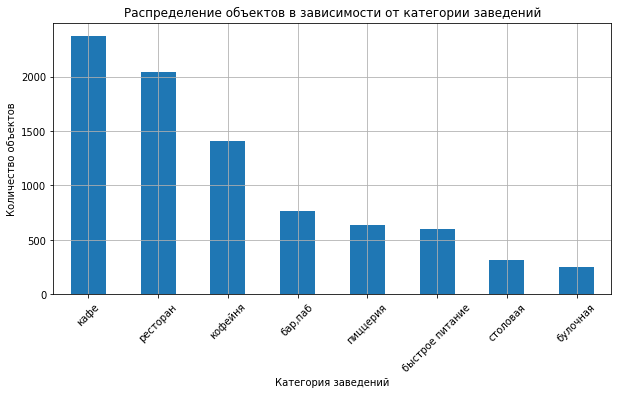

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 5))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['category'].value_counts().plot(
               kind='bar',
               rot=45,
               legend=False,
               title=f'Распределение объектов в зависимости от категории заведений'
)

# Настраиваем оформление графика
plt.xlabel('Категория заведений')
plt.ylabel('Количество объектов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Кафе и рестораны вместе занимают более половины рынка заведений общественного питания в Москве. Столовые и булочные — наименее представлены. Кофейни представляют собой достачтоно значительный сегмент рынка.

---

### Задача 2

Определим административные районы Москвы, представленные в данных. Подсчитаем количество заведений по каждому административному району. Отдельно проанализируем распределение заведений разных категорий в Центральном административном округе. Создадим подходящие визуализации для каждого этапа анализа. Опишем полученные результаты распределения.

In [ ]:
# Проверяем распределение данных по значениям столбца district в абсолютных и относительных значениях
print('Распределение данных по значениям столбца district:')
display(df['district'].value_counts())
display(round(df['district'].value_counts(normalize=True),2))

Распределение данных по значениям столбца district:


Центральный административный округ         2242
Северный административный округ             899
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

Центральный административный округ         0.27
Северный административный округ            0.11
Южный административный округ               0.11
Северо-Восточный административный округ    0.11
Западный административный округ            0.10
Восточный административный округ           0.09
Юго-Восточный административный округ       0.08
Юго-Западный административный округ        0.08
Северо-Западный административный округ     0.05
Name: district, dtype: float64

Данные представлены для 9-ти округов Москвы. Результаты анализа показывают концентрацию заведений общественного питания в Центральном административном округе, который значительно превосходит все остальные районы с 2242 объектами (27%). Это более чем в два раза превышает показатели Северного, Южного и Северо-Восточного административных округов, каждый из которых насчитывает около 900 заведений. Западный и Восточный округа имеют около 800 объектов, тогда как Юго-Восточный и Юго-Западный округа демонстрируют показатели около 700 заведений. Северо-Западный административный округ завершает список с наименьшим количеством — всего 409 объектов питания.


Визуализируем распределение в столбце `district`. Используем линейчатую диаграмму из-за длинных названий районов Москвы.

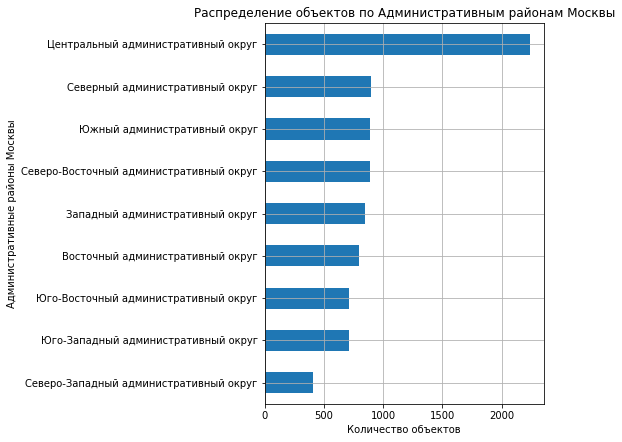

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(5, 7))

# Строим линейчатую диаграмму с помощью pandas через plot(kind='barh')
df['district'].value_counts().sort_values(ascending=True).plot(
               kind='barh',
               rot=0,
               legend=False,
               title=f'Распределение объектов по Административным районам Москвы'
)

# Настраиваем оформление графика
plt.ylabel('Административные районы Москвы')
plt.xlabel('Количество объектов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Распределение отражает централизованный характер развития инфраструктуры общественного питания в Москве. Остальные районы, кроме Северо-Западного, имеют близкие значения по количеству заведений.

Теперь отдельно проанализируем распределение заведений разных категорий в Центральном административном округе.

In [ ]:
# Проверяем распределение заведений разных категорий в Центральном административном округе
print('Распределение заведений разных категорий в Центральном административном округе:')
print(df.loc[df['district'] == 'Центральный административный округ']['category'].value_counts())
print(df.loc[df['district'] == 'Центральный административный округ']['category'].value_counts(normalize=True).round(2))

Распределение заведений разных категорий в Центральном административном округе:
ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64
ресторан           0.30
кафе               0.21
кофейня            0.19
бар,паб            0.16
пиццерия           0.05
быстрое питание    0.04
столовая           0.03
булочная           0.02
Name: category, dtype: float64



Визуализируем распределение с помощью столбчатой диаграммы.

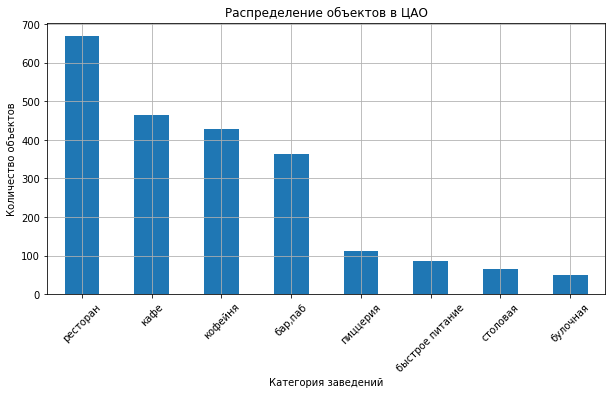

In [ ]:
part_centr = df.loc[df['district'] == 'Центральный административный округ']['category'].value_counts()
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 5))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
part_centr.plot(
               kind='bar',
               rot=45,
               legend=False,
               title=f'Распределение объектов в ЦАО'
)

# Настраиваем оформление графика
plt.xlabel('Категория заведений')
plt.ylabel('Количество объектов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Из анализа данных мы обнаружили, что Центральный административный округ Москвы лидирует по количеству заведений общественного питания, значительно опережая другие округа. В то же время Северо-Западный округ имеет наименьшее количество таких объектов.

В Центральном административном округе большинство заведений общественного питания составляют рестораны (30%), кафе (21%) и кофейни (19%). Значительно меньше заведений быстрого питания, столовых и булочных. Это говорит о том, что в округе преобладает формат более формального и размеренного досуга.

---

### Задача 3

Определим общее соотношение сетевых и несетевых заведений по всем данным. Проанализируем распределение сетевых и несетевых заведений в разрезе каждой категории. Выявим категории с наибольшей долей сетевых заведений. Построим визуализации для общего соотношения и распределения по категориям. Сформулируем выводы о преобладающем типе заведений и наиболее частых сетевых категориях.

In [ ]:
# Определяем общее соотношение сетевых и несетевых заведений по всем данным в абсолютных и относительных значениях.
print('Распределение данных по значениям столбца chain:')
display(df['chain'].value_counts())
display(round(df['chain'].value_counts(normalize=True),2))

Распределение данных по значениям столбца chain:


False    5200
True     3203
Name: chain, dtype: int64

False    0.62
True     0.38
Name: chain, dtype: float64

Несетевые заведения значительно преобладают над сетевыми в общем распределении: 5201 заведение общественного питания или 62% являются несетевыми, в то время как только 3205 заведений или 38% относятся к сетевым.

Визуализируем соотношение.



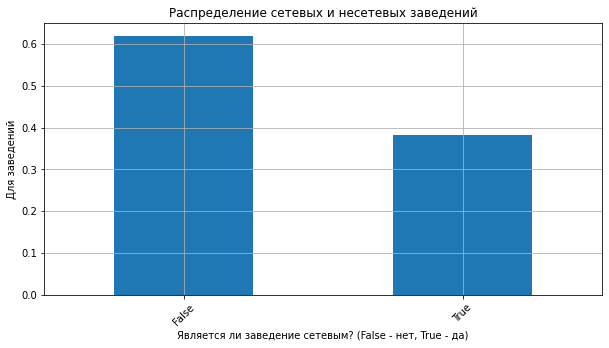

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 5))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['chain'].value_counts(normalize=True).plot(
               kind='bar',
               rot=45,
               legend=False,
               title=f'Распределение сетевых и несетевых заведений'
)

# Настраиваем оформление графика
plt.xlabel('Является ли заведение сетевым? (False - нет, True - да)')
plt.ylabel('Для заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Теперь рассмотрим распределение сетевых и несетевых объектов в разрезе категорий заведений.

In [ ]:
# Проанализируем распространение сетевых и несетевых объектов по категориям с помощью группировки - метода groupby()
display(df.groupby('chain')['category'].value_counts())
display(df.groupby(['chain'])['category'].value_counts(normalize=True).round(2))

chain  category       
False  кафе               1598
       ресторан           1313
       кофейня             693
       бар,паб             596
       быстрое питание     371
       пиццерия            303
       столовая            227
       булочная             99
True   кафе                779
       ресторан            729
       кофейня             720
       пиццерия            330
       быстрое питание     232
       бар,паб             168
       булочная            157
       столовая             88
Name: category, dtype: int64

chain  category       
False  кафе               0.31
       ресторан           0.25
       кофейня            0.13
       бар,паб            0.11
       быстрое питание    0.07
       пиццерия           0.06
       столовая           0.04
       булочная           0.02
True   кафе               0.24
       ресторан           0.23
       кофейня            0.22
       пиццерия           0.10
       быстрое питание    0.07
       бар,паб            0.05
       булочная           0.05
       столовая           0.03
Name: category, dtype: float64

Перейдем сразу к визуализации, чтобы описать распределение.

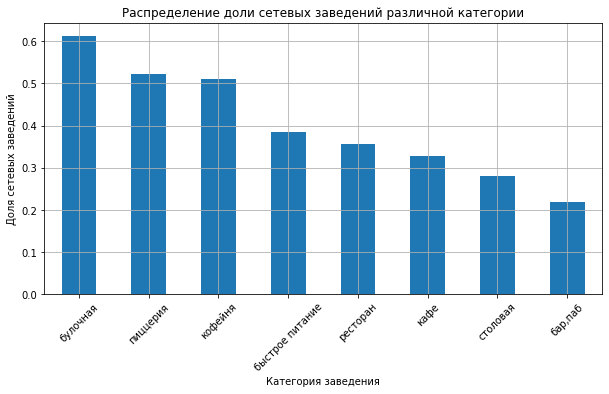

In [ ]:
# Построим график столбчатой диаграммы

df.groupby('category')['chain'].mean().sort_values(ascending=False).plot(kind='bar',
               title=f'Распределение доли сетевых заведений различной категории',
               legend=False,
               ylabel='Доля сетевых заведений',
               xlabel='Категория заведения',
               rot=45,
               figsize=(10, 5)
                      )
plt.grid()
# Выводим график
plt.show()

In [ ]:
df.groupby('category')['chain'].mean().sort_values(ascending=False)

category
булочная           0.613281
пиццерия           0.521327
кофейня            0.509554
быстрое питание    0.384743
ресторан           0.357003
кафе               0.327724
столовая           0.279365
бар,паб            0.219895
Name: chain, dtype: float64

Сетевые и несетевые заведения различным образом представлены по категориям заведений. Самая большая доля сетевых заведений по категориям у булочных (61%), чуть больше половины у пиццерий (52%) и кофеин (51%).  По остальным категориям доля сетевых заведений ниже половины: быстрое питание (38%), ресторан (36%), кафе (33%), столовая (28%), бар/паб (22%).

---

### Задача 4

Исследуем количество посадочных мест в заведениях. Проверим наличие аномальных значений и выбросов. Определим наиболее типичное количество посадочных мест для каждой категории заведений. Построим подходящие визуализации для анализа распределения. Проанализируем возможные причины аномальных значений.


Вначале стоит оценить статические показатели столбца `seats`. Будем использовать для этого метод describe().

In [ ]:
# Изучаем статистические показатели столбца seats
print('Статистические показатели столбца seats:')
df['seats'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

Статистические показатели столбца seats:


count    4792.000000
mean      108.361435
std       122.841133
min         0.000000
5%          6.000000
25%        40.000000
50%        75.000000
75%       140.000000
95%       307.000000
99%       625.000000
max      1288.000000
Name: seats, dtype: float64

Скорее всего, данные по количеству посадочных мест имеют асимметричное, скошенное вправо распределение. На это указывает разница между средним (108.42) и медианным (75) значениями. Значение стандартного отклонения высокое — 122.83, учитывая среднее 108.42. Это указывает, что данные могут иметь широкий разброс. Разница между минимальным и максимальным значениями это подтверждает: 0 и 1288. <br>
Построим гистограмму по данным столбца `seats`.

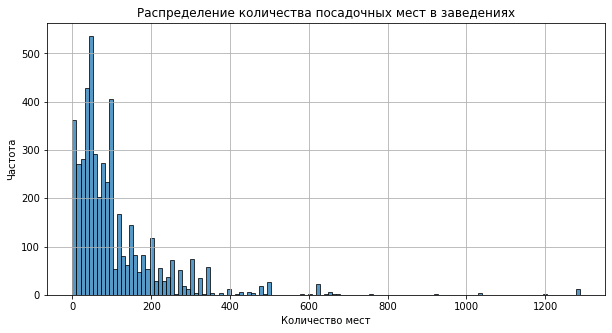

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 5))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['seats'].plot(
                kind='hist',
                bins=125,
                alpha=0.75,
                edgecolor='black',
                rot=0,
)

# Настраиваем оформление графика
plt.title('Распределение количества посадочных мест в заведениях')
plt.xlabel('Количество мест')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Гистограмма показывает, что распределение количества посадочных мест в заведения асимметричное и скошено вправо. Значит среди значений есть заведения с нетипично большим количеством посадочных мест. Построим диаграмму размаха для оценки выбросов и аномальных значений.

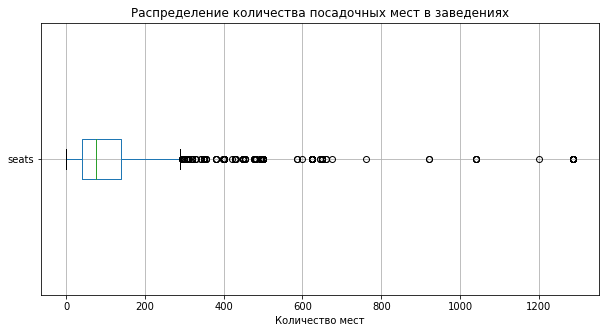

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 5))

# Строим диаграмму размаха значений в столбце seats
df.boxplot(column='seats', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение количества посадочных мест в заведениях')
plt.xlabel('Количество мест')

# Выводим график
plt.show()

На диаграмме размаха можно увидеть выбросы — значения, которые значительно выше (в нашем случае именно выше) основного диапозона данных. Можно наблюдать плотную группу экстримаельный значений, которая находится от верхнего порога распределения (верхний порог = Q3 + 1.5 * IQR, то есть третий квартиль (75-й процентиль) плюс полтора межквартильных размаха) до примерно 99-го процентиля, которому соответствует значение 625.<br>
Рассмотрим детально заведения, где количество посадочных мест выше этого значения.

In [ ]:
outliers_seats = df['seats'].quantile(0.99)
display(df.loc[df['seats'] > outliers_seats])

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
2711,8d07e2d1810b4dca9d4cb247d0335df3,Ваня И Гоги,"бар,паб","Москва, Измайловское шоссе, 71, корп. А",Восточный административный округ,"ежедневно, 11:00–06:00",4.2,False,1040.0,высокие,Средний счёт:1000–2500 ₽,1750.0,NaN,False
2720,4731af3e68bb449fb2b34493fadfaed1,Маргарита,быстрое питание,"Москва, Измайловское шоссе, 71, корп. А",Восточный административный округ,"ежедневно, 10:00–22:00",4.3,True,1040.0,NaN,NaN,NaN,NaN,False
2768,4c196f841b0046b3ab3a60d3ed52bfc5,Шоколадница,кофейня,"Москва, Измайловское шоссе, 71, корп. А",Восточный административный округ,"пн-ср 11:00–23:00; чт 11:00–00:00; пт,сб 11:00...",4.1,True,1040.0,NaN,NaN,NaN,NaN,False
2899,4a603ed5bc6043b7890ef13369e063ec,Ресторан Тройка,"бар,паб","Москва, Измайловское шоссе, 71, корп. 2Б",Восточный административный округ,"ежедневно, 11:00–23:00",3.7,False,660.0,NaN,NaN,NaN,NaN,False
2911,abb5ad187013434c8c70f49c69ed1bb1,Хаус Бар,"бар,паб","Москва, Измайловское шоссе, 71, корп. 2Б",Восточный административный округ,"ежедневно, 07:00–23:00",3.7,False,660.0,средние,Средний счёт:500–1000 ₽,750.0,NaN,False
2964,6b611f2fc2084078952aaef40780f11c,Матрешка,кафе,"Москва, Измайловское шоссе, 71, корп. А",Восточный административный округ,NaN,4.0,False,1040.0,NaN,NaN,NaN,NaN,False
4177,77141ea2e18e4f06867b6fef81f2aae4,Eataly,"бар,паб","Москва, Киевская улица, 2",Западный административный округ,"ежедневно, 12:00–23:00",4.6,False,920.0,NaN,NaN,NaN,NaN,False
4228,30d6c2abb42748bb98c01b1ed366e253,Рестобар Argomento,столовая,"Москва, Кутузовский проспект, 41, стр. 1",Западный административный округ,"ежедневно, 12:00–23:00",4.2,False,1200.0,высокие,Средний счёт:2500–5000 ₽,3750.0,NaN,False
4242,1444de238c0f4de8a1de18ed0cb418f7,Стейк & Бургер,кафе,"Москва, Киевская улица, 2",Западный административный округ,"ежедневно, 09:00–21:00",4.2,True,920.0,NaN,NaN,NaN,NaN,False
5483,d355bd6aaadc4bacb006347f0662e196,Дом,кафе,"Москва, улица Юности, 1",Восточный административный округ,NaN,4.9,False,760.0,NaN,NaN,NaN,NaN,False


Среди экстремально  высоких значений по количеству посадочных мест (выше 99-ой процентиля) обращают на себя внимания заведения, расположенные по адресам: Москва, Измайловское шоссе, 71, корп. А, Москва, проспект Вернадского, 121, корп. 1, Москва, проспект Вернадского, 41, стр. 1. Количество посадочных мест в этих заведениях одинаковое для каждого адреса. Например, у всех заведений по адресу Москва, Измайловское шоссе, 71, корп. А количество посадочных мест — 1040. Такое большое число, скорее всего, указывает на то, что в этом здании есть фудкорт (в данном случае по этому адресу находится торговый центр, на верхнем этаже которого расположен фудкорт). Само по себе наличие в датасете футдкортов не представляет проблемы, однако сложность возникает с тем, как считать посадочные места для каждого заведения. В нашем примере каждому заведению на Измайловское шоссе, 71, корп. А было присвоено общее количество посадочных мест фудкорта (1040). Учитывая, что по этому адресу расположены 4 заведения общественного питания, то, согласно данным, там находится пространство на 4160 посадочных мест (4 * 1040), что не верно. В целом способ определения мест ведет к аномальным значениям, что может исказить результаты анализа.
<br>
<br>
Другой важный момент — это одинаковое количество посадочным мест (1288) для целого ряда адресов по улице Вернадского: проспект Вернадского, 94, корп. 1, проспект Вернадского, 121, корп. 1, проспект Вернадского, 97, корп. 1, проспект Вернадского, 84, стр. 1, проспект Вернадского, 51, стр. 1. Скорее всего, это техническая ошибка.
<br>
<br>
Возможно, в столбце `seats` есть и другие аномальные значения, вызванные техническими ошибками, но мы пока остановимся на тех, кто обнаружили и заменим их на пропуски.


Теперь определим наиболее типичное количество посадочных мест для каждой категории заведений. Поскольку распределение числа посадочных мест ассимитрично и имеет выраженные выбросы, среднее не отражает реальную «середину» данных. Более надёжной характеристикой типичного значения является медиана.

In [ ]:
# Создаем сводную таблицу
tab_seats = df.pivot_table(index='category', values='seats', aggfunc=['mean', 'median']).sort_values(('mean', 'seats'), ascending=False)
display(tab_seats)

,mean,median
,seats,seats
category,,
"бар,паб",124.477516,82.0
ресторан,121.892044,86.0
кофейня,111.199730,80.0
столовая,99.750000,75.5
быстрое питание,98.891121,65.0
кафе,97.365654,60.0
пиццерия,94.496490,55.0
булочная,89.385132,50.0



Построим визуализацию медианных значений по количеству посадочных мест разных категорий заведений.

In [ ]:
tab_seats[('median', 'seats')].sort_values(ascending=False)

category
ресторан           86.0
бар,паб            82.0
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: (median, seats), dtype: float32

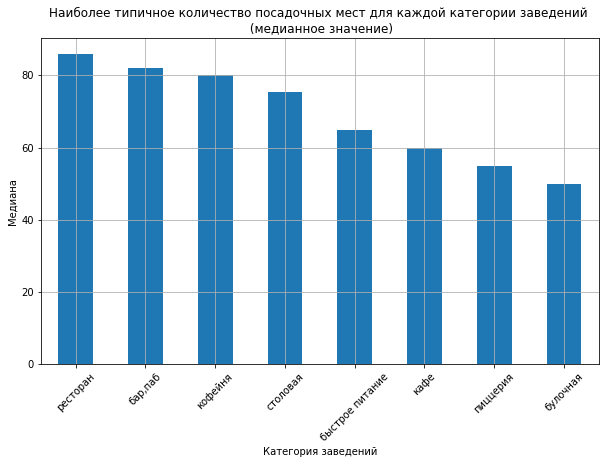

In [ ]:
# Построим график столбчатой диаграммы
tab_seats[('median', 'seats')].sort_values(ascending=False).plot(kind='bar',
               title=f'Наиболее типичное количество посадочных мест для каждой категории заведений \n (медианное значение)',
               ylabel='Медиана',
               xlabel='Категория заведений',
               rot=45,
               figsize=(10, 6)
                      )
plt.grid()
# Выводим график
plt.show()



Поскольку в распределении значений в столбце `seats` встречаются выбросы и аномальные значения, мы сосредоточем свое внимание прежде всего на медиане, как центральной мере, которая менее чувтсвительна к выбросам. <br>
Рестораны имеют наибольшее медианное значение посадочных мест — 86. Это говорит о том, что рестораны обычно предлагают большое количество мест для посетителей и разные форматы проведения мероприятий (свадьбы, юбилеи, карпоративы). Бары и пабы также имеют высокое медианное значение по количеству посадочных мест — 82. Кофейни следуют с показателем 80 мест. У столовых и заведений быстрого питания количество мест составляет 75.5 и 65, соответственно. Кафе имеют 60 мест, пиццерии — 53.5, а булочные — 50.
<br>
Если обратиться к средним значениям, то заметно значительное различие между категориями ресторанов и баров/пабов и следующей за ними категорией — кофейнями. Это может указывать на то, что в категориях ресторанов и баров/пабов присутствуют больше экстремально высоких значений по количеству посадочных мест (либо эти экстримальные значения более выражены).

Таким образом, рестораны и бары имеют наибольшее количество посадочных мест, в то время как булочные и пиццерии предлагают меньше мест для посетителей.

---

### Задача 5

Исследуем рейтинг заведений. Визуализируем распределение средних рейтингов по категориям заведений. Проанализируем различия усреднённых рейтингов для разных типов общепита.

Опять же начнем с оценки статических показателей столбца rating с помощью метода describe().

In [ ]:
# Изучаем статистические показатели столбца rating
print('Статистические показатели столбца seats:')
df['rating'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

Статистические показатели столбца seats:


count    8403.000000
mean        4.229894
std         0.470426
min         1.000000
5%          3.400000
25%         4.100000
50%         4.300000
75%         4.400000
95%         4.800000
99%         5.000000
max         5.000000
Name: rating, dtype: float64

Судя по описательной статистике, распределение оценок (rating) близко к нормальному, но немного скошено влево. Среднее значение (4.22) и медиана (4.3) находятся близко друг к другу, что указывает на относительную симметрию распределения. Однако 5-й процентиль равен 3.4, а 95-й — 4.8. Большая часть значений сконцентрирована в диапазоне от 4.1 до 4.4, что подтверждает концентрацию оценок вокруг среднего уровня. Минимальное значение оценки равно 1, а максимальное — 5, что соответствует стандартной 5-ти бальной шкале рейтинга. Стандартное отклонение составляет 0.47, что указывает на умеренный разброс значений вокруг среднего. Только около 1% заведений имеют рейтинг 5.

Теперь построим гистограмму распределения.

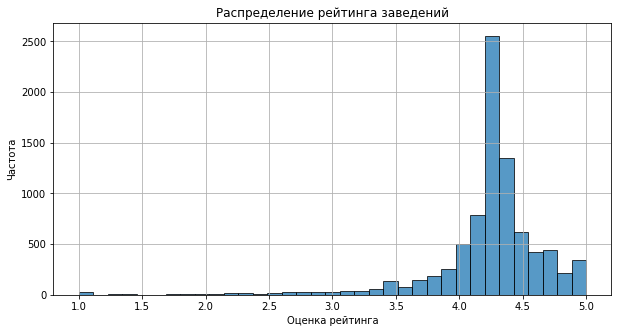

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 5))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['rating'].plot(
                kind='hist',
                bins=35,
                alpha=0.75,
                edgecolor='black',
                rot=0,
)

# Настраиваем оформление графика
plt.title('Распределение рейтинга заведений')
plt.xlabel('Оценка рейтинга')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

По гистограмме видно, что распределение ассимитричное с длинным хвостом слева. Это достаточно ожидаемое распределение, когда речь идет о рейтингах представленных в виде шкалы оценок. Мы также наблидаем небольшой пик справа — оценки 5. Центральнаяя мера находится в пределах 4.2-4.3.

Далее проанализируем распределение средних рейтингов по категориям заведений.

In [ ]:
# Выведем вариации средних рейтингов по категориям заведений
tab_rating = df.groupby('category')['rating'].describe(percentiles=[.25, .5, .75]).sort_values(('mean'), ascending=False)
display(tab_rating)

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
"бар,паб",764.0,4.387697,0.380392,1.1,4.3,4.4,4.6,5.0
пиццерия,633.0,4.301264,0.336162,1.0,4.2,4.3,4.4,5.0
ресторан,2042.0,4.290401,0.413143,1.0,4.2,4.3,4.5,5.0
кофейня,1413.0,4.277282,0.372250,1.4,4.1,4.3,4.4,5.0
булочная,256.0,4.268360,0.386303,1.3,4.2,4.3,4.4,5.0
столовая,315.0,4.211429,0.454205,1.0,4.1,4.3,4.4,5.0
кафе,2377.0,4.123896,0.566200,1.0,4.0,4.2,4.4,5.0
быстрое питание,603.0,4.050249,0.560949,1.1,3.9,4.2,4.3,5.0


Значения усредненных рейтингов для разных типов заведений различаются. Наивысший средний рейтинг у баров/пабов (4.38), затем следуют пиццерии (4.30) и рестораны (4.29). Самые низкие показатели у заведений быстрого питания (4.05) и кафе (4.12). Медианные значения близки к средним арифметическим. Несмотря на различия заметим, что рейтинги типов объектов общественного питания достаточно близки: например, разница в среднем рейтинге ресторанов и булочных равняется 0.22. Это может указывать на то, что разные типы заведений оцениваются людьми по характерным для этого типа характеристикам. В любом случае различия в рейтингах стоит оценить статистически, чтобы понять их значимость.

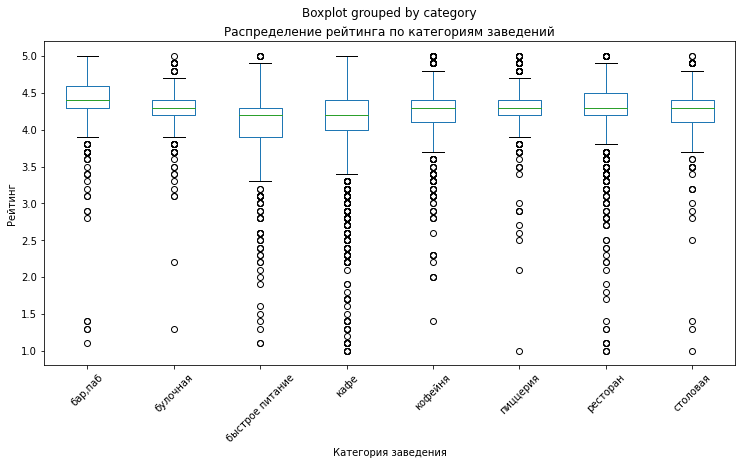

In [ ]:
# Построим диаграмму размаха
df.boxplot(
    column='rating',
    by='category',
    rot=45,
    grid=False,
    figsize=(12, 6)
)
plt.title("Распределение рейтинга по категориям заведений")

plt.xlabel('Категория заведения')
plt.ylabel('Рейтинг')
plt.show()

Рейтинги большинства категорий заведений сосредоточены в узком диапазоне 4.0-4.5. Наиболее высокие медианные значения имеют бары/пабы, пиццерии и рестораны. Самый большой разброс значений у кафе, заведений быстрого питания. У быстрого питания медиана ниже (около 4.2), чем у других категорий. Примечательно, что у ресторанов также достаточно сильно варьируются значения рейтинга - встречаются заведения с рейтингом меньше 2. Самые скученные оценки у пиццерий.

---

### Задача 6

Построим матрицу корреляции рейтинга заведений с категорией, административным районом, сетевым статусом, количеством мест, ценовой категорией и признаком круглосуточной работы. Визуализируем матрицу корреляции. Выявим самую сильную связь. Проверим выявленную корреляцию.

In [ ]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = df[['category', 'district', 'chain', 'seats', 'price',
                         'is_24_7', 'rating']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['seats', 'rating']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.262056
category,0.198917
district,0.189389
is_24_7,0.160864
chain,0.119061
seats,0.000000


Наибольшая корреляция рейтинга заведения наблюдается с ценовой категорией (0.262), типом заведения (0.198) и районом (0.189). Заметим, что значения корреляции от 0 до 0.3 интерпретируются как слабая корреляция. Для остальных признаков коэффициент корреляции снижается с 0.16 до 0.

Далее нам необходимо будет определить характер обнаруженной связи между рейтингом и другими признаками. Но перед этим визуализируем результат корреляции с помощью тепловой карты и библиотеки seaborn.

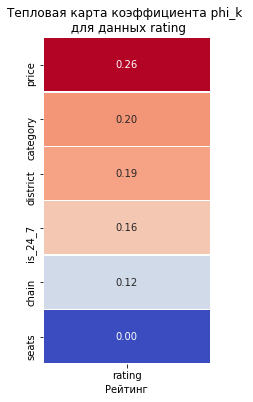

In [ ]:
# Строим тепловую карту
plt.figure(figsize=(3, 6))

# Сохраняем матрицу корреляции признака rating с другими признаками заведений общепита
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            cbar=False
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Рейтинг')


# Выводим график
plt.show()

После того, как мы построили тепловую карту коррелиции, приступим к анализу характера взаимосвязи рейтинга с другими признаками. В конце рассмотрим самую сильную связь, которая есть у рейтинга с ценовой категорией заведения.

Изучим, существует ли зависимость между рейтингом заведения и сетевым статусом. Для этого построим столбчатую диаграмму.

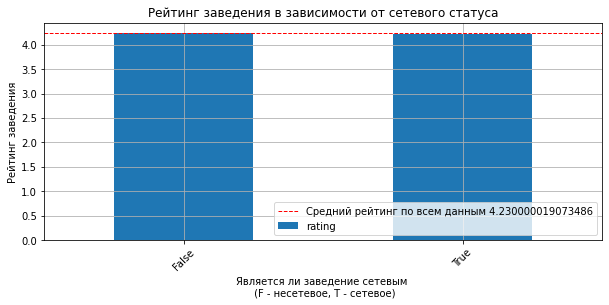

chain
False    4.235442
True     4.220887
Name: rating, dtype: float32

In [ ]:
# Построим график столбчатой диаграммы
grouped_chain = df.groupby('chain')['rating'].mean()
grouped_chain.plot(kind='bar',
               title=f'Рейтинг заведения в зависимости от сетевого статуса',
               legend=True,
               ylabel='Рейтинг заведения',
               xlabel='Является ли заведение сетевым \n (F - несетевое, T - сетевое)',
               rot=45,
               figsize=(10, 4))

# Рассчитываем среднее значение по рейтингу для всех заведений
mean_rating_gen = df['rating'].mean()

# Наносим на график линию с средним значением рейтинга заведения
plt.axhline(mean_rating_gen,
            color='red',
            linestyle='--',
            linewidth=1,
            label=f'Средний рейтинг по всем данным {round(mean_rating_gen,3)}')
# Выводим сетку
plt.grid()

# Выводим легенду и местом ее размещения на графике
plt.legend(loc='lower right')

# Выводим график
plt.show()

display(df.groupby('chain')['rating'].mean())

Сетевой статус заведения — является ли заведение сетевым или нет — не влияет на рейтинг.

Cделаем пользовательскую функцию, чтобы выполнить анализ для других признаков.

In [ ]:
# Задаём функцию для анализа данных
def plot_bar_plot(df, groupby, value, aggfunc, title, ylabel, xlabel):
    '''
    Функция для анализа распределения метрики по признакам:
    df - датафрейм с данными для анализа;
    groupby - str, название столбца для группировки данных;
    value - str, название столбца, значение которого будет агрегироваться;
    aggfunc - str, функция агрегации, которая используется для расчёта;
    title - str, заголовок графика;
    ylabel - str, подпись по оси Y;
    xlabel - str, подпись по оси X.
    '''
    grouped = df.groupby(groupby).agg({value:aggfunc})
    grouped.plot(kind='bar',
                   title=title,
                   legend=True,
                   ylabel=ylabel,
                   xlabel=xlabel,
                   rot=45,
                   figsize=(10, 4))

    # Рассчитываем общее значение value по всем данным
    mean_churn_mean = df.agg({value:aggfunc})[0]

    # Наносим на график линию с значением value по всем данным
    plt.axhline(mean_churn_mean, color='red',
                linestyle='--', linewidth=1,
                label=f'Средний рейтинг по всем данным {round(mean_churn_mean,3)}')

    # Выводим сетку
    plt.grid()

    # Выводим легенду и местом ее размещения на графике
    plt.legend(loc='lower right')

    # Выводим график
    plt.show()

Применим функцию и изучим распределение рейтинга в зависимости от признака, является ли заведения круглосуточным (столбец is_24_7).

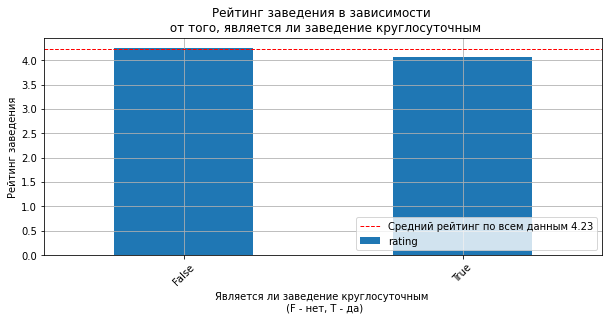

In [ ]:
# Применим функцию и изучим распределение рейтинга в зависимости от признака, является ли заведения круглосуточным.
title='Рейтинг заведения в зависимости \n от того, является ли заведение круглосуточным'
xlabel='Является ли заведение круглосуточным \n (F - нет, T - да)'
ylabel='Рейтинг заведения'

plot_bar_plot(df, 'is_24_7', 'rating', 'mean', title, ylabel, xlabel)


Средний рейтинг у круглосуточных заведений составил 4.07 и он ниже, чем у некруглосуточных  заведений 4.24.

Теперь посмотрим на связь рейтинга с типом заведения. Для снова этого применим функцию plot_bar_plot.

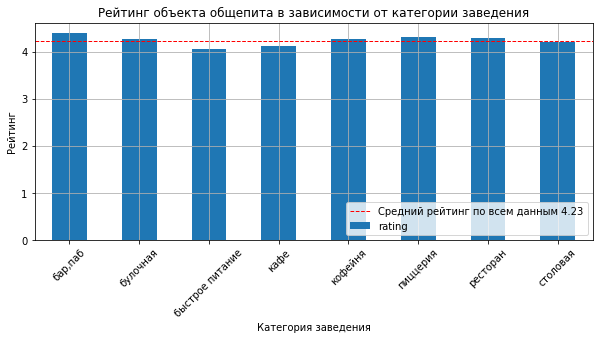

In [ ]:
# Применим функцию и изучим распределение рейтинга в зависимости от типа заведения.
title='Рейтинг объекта общепита в зависимости от категории заведения'
xlabel='Категория заведения'
ylabel='Рейтинг'

plot_bar_plot(df, 'category', 'rating', 'mean', title, ylabel, xlabel)


На диаграмме видно, что есть определенная зависимость между рейтингом и категорией заведения, хотя значения находятся примерно около среднего. Различия наблюдается для рейтинга пабов/баров (4.39), пиццерии (4.30) и ресторанов (4.29) — они выше, чем средний рейтинг по всем данным (4.23). Кроме того от среднего рейтинга, только в меньшую сторону, отличаются рейтинги заведений, которые относятся заведения быстрого питания (4.05) и кафе (4.12).

Теперь рассмотрим взаимосвязь рейтинга и административного района заведения. Для этого построим линейчатую диаграмму.

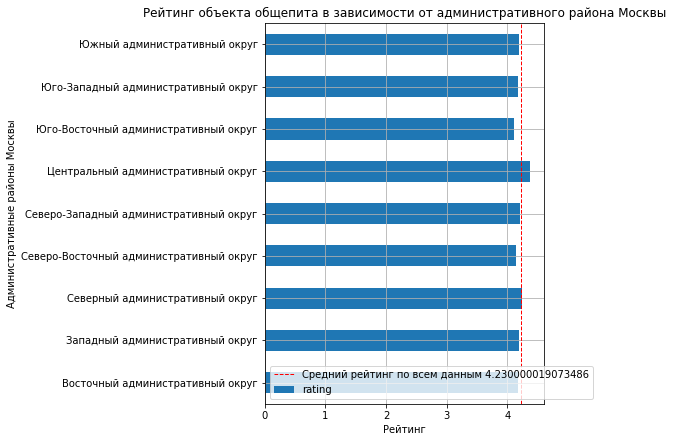

In [ ]:
# Создаем переменную, которая будет хранить средний рейтинг в разрезе административных округов Москвы
grouped_district = df.groupby('district')['rating'].mean()

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(5, 7))

# Строим линейчатую диаграмму с помощью pandas через plot(kind='barh')
grouped_district.plot(
               kind='barh',
               rot=0,
               legend=False,
               title=f'Рейтинг объекта общепита в зависимости от административного района Москвы'
)

# Наносим на график линию с средним значением рейтинга заведения
plt.axvline(mean_rating_gen,
            color='red',
            linestyle='--',
            linewidth=1,
            label=f'Средний рейтинг по всем данным {round(mean_rating_gen,3)}')

# Настраиваем оформление графика
plt.ylabel('Административные районы Москвы')
plt.xlabel('Рейтинг')

# Добавляем сетку графика
plt.grid()

plt.legend(loc='lower left')

# Выводим график
plt.show()

Средние значения рейтингов в зависимости от районов находятся примерно около среднего значения по всем данным. Однако можно выделить несколько кейсов. Выделяется высоким средним рейтингом Центральный административный округ (4.37). Ниже среднего по всем данным средний рейтинг в Восточный административный округ (4.17), Северо-Восточный административный округ (4.14), Юго-Восточный административный округ (4.10), Юго-Западный административный округ (4.17). Чуть выше рейтинги в Западном административном округе, Южном административном округе (4.18), Северо-Западном административном округе (4.20), Северный административный округ (4.23). В целом на востоке Москвы рейтинг ниже, но различия небольшие.

Наконец, посмотрим на связь рейтинга и ценовой категорией. Корреляционная матрица показала, у рейтинга заведений самая сильная связь именно с категориями цен. Посмотрим на эту связь внимательнее.

In [ ]:
# Проведем расчет значений
df.groupby('price')['rating'].mean().sort_values(ascending=False)

price
высокие          4.436611
выше среднего    4.386348
средние          4.297874
низкие           4.173077
Name: rating, dtype: float32

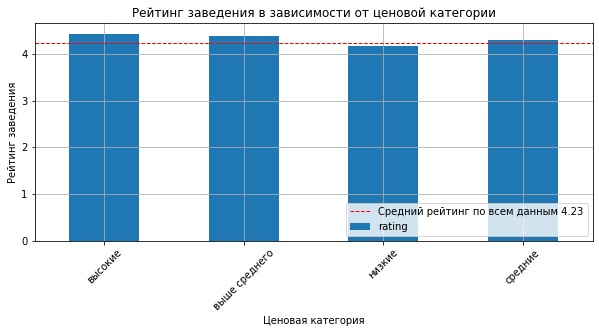

In [ ]:
# Применим функцию и изучим распределение рейтинга в зависимости от типа заведения.
title='Рейтинг заведения в зависимости от ценовой категории'
xlabel='Ценовая категория'
ylabel='Рейтинг заведения'

plot_bar_plot(df, 'price', 'rating', 'mean', title, ylabel, xlabel)

Здесь видно, что есть чёткая взаимосвязь (позитивная корреляция) между признаками: чем выше ценовая категория, тем выше средний рейтинг.

- высокая ценовая категория: средний рейтинг 4.43;
- выше среднего: средний рейтинг 4.38;
- средняя: средний рейтинг 4.29;
- низкая: 4.17;


Можно проинтерпретировать связь ценовой категории заведения с рейтингом так: более дорогие заведения, как правило, уделяют больше внимания качеству обслуживания и атмосфере, что отражается в оценках гостей. В низкой ценовой категории разброс качества выше, а средние рейтинги ниже.

---

### Задача 7

Сгруппируем данные по названиям заведений и найдем топ-15 популярных сетей в Москве по количеству заведений. Для этих сетей посчитаем значения среднего рейтинга. Определим к какой категории заведений они относятся. Результат сопроводим подходящими визуализациями.

In [ ]:
# Находим топ-15 самых популярных сетей по количеству заведений
top_15 = df[df['chain']].groupby(['name','category'])['rating'].agg(['count','mean']).sort_values('count', ascending=False).head(15).reset_index()
display(top_15)

,name,category,count,mean
0,Шоколадница,кофейня,119,4.178151
1,Домино'С Пицца,пиццерия,76,4.169737
2,Додо Пицца,пиццерия,74,4.286487
3,One Price Coffee,кофейня,71,4.064789
4,Яндекс Лавка,ресторан,69,3.872464
5,Cofix,кофейня,65,4.075385
6,Prime,ресторан,49,4.114285
7,Кофепорт,кофейня,42,4.147619
8,Кулинарная Лавка Братьев Караваевых,кафе,39,4.394872
9,Теремок,ресторан,36,4.105556


In [ ]:
# Комментарий ревьюера
tmp = df.copy()          # создаем копию текущего датасета
name_tmp = 'Му-Му'       # задаем имя столбца для проверки уникальных категорий
print(f'Заведения с одинаковым именем {name_tmp} относятся к разным категориям:\n\
{", ".join(tmp[tmp.name == name_tmp].category.unique())}')

Заведения с одинаковым именем Му-Му относятся к разным категориям:
кафе, ресторан, кофейня, быстрое питание, пиццерия, столовая, бар,паб


Мы получили топ-15 самых популярных сетей. Заведение "Шоколадница" — самая популярная сеть, в которой 119 заведений. Построим линейчатую диаграмму с топ-15.

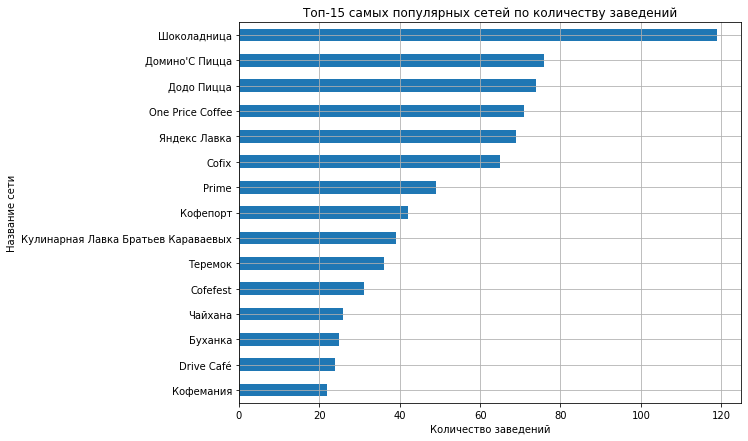

In [ ]:

# Строим линейчатую диаграмму с помощью pandas через plot(kind='barh')
top_15[['name', 'count']].set_index('name').sort_values('count', ascending=True).plot(kind='barh',
               title=f'Топ-15 самых популярных сетей по количеству заведений',
               legend=False,
               rot=0,
               figsize=(9, 7))

# Настраиваем оформление графика
plt.ylabel('Название сети')
plt.xlabel('Количество заведений')

# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

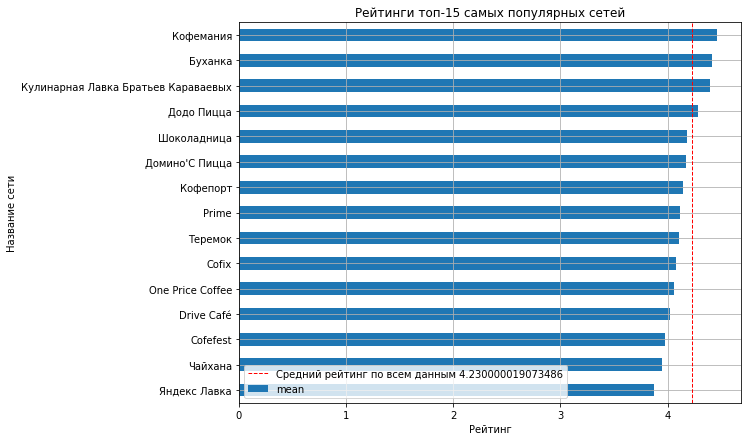

In [ ]:

# Строим линейчатую диаграмму с помощью pandas через plot(kind='barh')
top_15[['name', 'mean']].set_index('name').sort_values('mean', ascending=True).plot(kind='barh',
               title=f'Рейтинги топ-15 самых популярных сетей',
               legend=False,
               rot=0,
               figsize=(9, 7))

# Настраиваем оформление графика
plt.ylabel('Название сети')
plt.xlabel('Рейтинг')

# Наносим на график линию с средним значением рейтинга заведения
plt.axvline(mean_rating_gen,
            color='red',
            linestyle='--',
            linewidth=1,
            label=f'Средний рейтинг по всем данным {round(mean_rating_gen,3)}')

# Добавляем сетку графика
plt.grid()

# Добавляем легенду
plt.legend(loc='lower left')

# Выводим график
plt.show()

Самые высокие рейтинги у сетей "Кофемания", "Буханка", "Кулинарная Лавка Братьев Караваевых", "Додо Пицца". У всех перечисленных сетевых заведений средний рейтинг выше, чем средний рейтинг заведений по всем данным.



Последняя вопрос в этой задаче — определим к какой категории заведений эти сетевые заведения относятся.

In [ ]:
# Еще раз выведем таблицу с топ-15 заведений
display(top_15)

,name,category,count,mean
0,Шоколадница,кофейня,119,4.178151
1,Домино'С Пицца,пиццерия,76,4.169737
2,Додо Пицца,пиццерия,74,4.286487
3,One Price Coffee,кофейня,71,4.064789
4,Яндекс Лавка,ресторан,69,3.872464
5,Cofix,кофейня,65,4.075385
6,Prime,ресторан,49,4.114285
7,Кофепорт,кофейня,42,4.147619
8,Кулинарная Лавка Братьев Караваевых,кафе,39,4.394872
9,Теремок,ресторан,36,4.105556




</font><font color='Black'> В топ-15 самых популярных сетей вошли: 1 булочная, 2 пиццерии, 3 кафе, 3 ресторана, 5 кофеин. Самый популярной сетью с точки зрения рейтинга оказалась кофейня "Кофемания". Самой популярной сетью с точки зрения количества филиалов - "Шоколадница".

---

### Задача 8

Изучим вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируем цены в Центральном административном округе и других. Изучим как удалённость от центра влияет на цены в заведениях. Результат сопроводим подходящими визуализациями.

In [ ]:
# Изучим статистические показатели столбца middle_avg_bill
df['middle_avg_bill'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count     3149.000000
mean       958.053650
std       1009.732849
min          0.000000
5%         225.000000
25%        375.000000
50%        750.000000
75%       1250.000000
95%       2250.000000
99%       3750.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

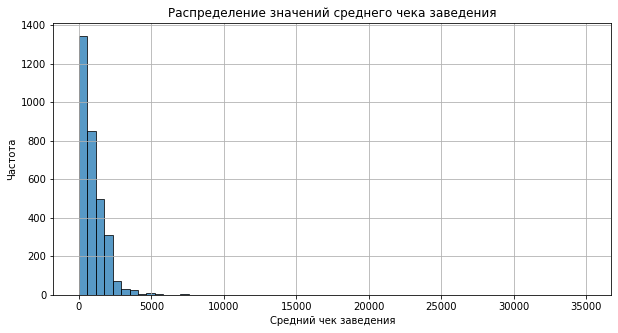

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 5))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['middle_avg_bill'].plot(
                kind='hist',
                bins=60,
                alpha=0.75,
                edgecolor='black',
                rot=0,
)

# Настраиваем оформление графика
plt.title('Распределение значений среднего чека заведения')
plt.xlabel('Cредний чек заведения')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

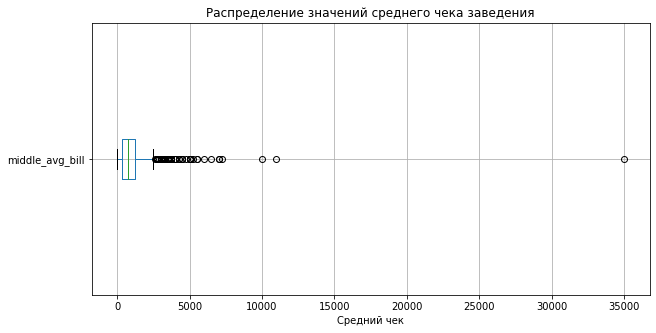

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 5))

# Строим диаграмму размаха значений в столбце seats
df.boxplot(column='middle_avg_bill', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений среднего чека заведения')
plt.xlabel('Средний чек')

# Выводим график
plt.show()

Распределение среднего чека заведения асимметричное и скошено вправо. Среднее значение составило 958.05 и оно больше чем медиана, что указывает на экстримальные значения справа. Учитывая эти особенности, лучше использовать медиану для расчета центральной меры чека в заведениях.

In [ ]:
# Вычисляем медианный средний чек по районам и сортируем по убыванию
median_avg_bill = df.groupby('district')['middle_avg_bill'].agg(['median','mean']).reset_index()
# Выводим результат
display(median_avg_bill)

,district,median,mean
0,Восточный административный округ,575.0,820.626953
1,Западный административный округ,1000.0,1053.225464
2,Северный административный округ,650.0,927.959656
3,Северо-Восточный административный округ,500.0,716.611267
4,Северо-Западный административный округ,700.0,822.222900
5,Центральный административный округ,1000.0,1191.057495
6,Юго-Восточный административный округ,450.0,654.097961
7,Юго-Западный административный округ,600.0,792.561707
8,Южный административный округ,500.0,834.398071


<Figure size 720x360 with 0 Axes>

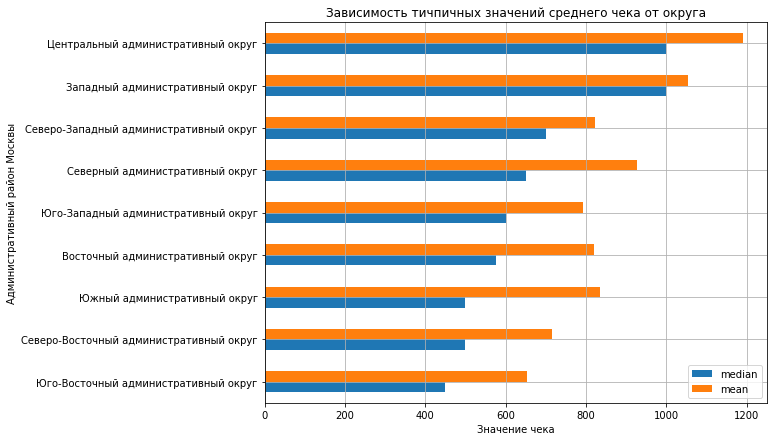

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 5))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
median_avg_bill.set_index('district').sort_values('median', ascending=True).plot(kind='barh',
               title=f'Зависимость тичпичных значений среднего чека от округа',
               legend=False,
               rot=0,
               figsize=(9, 7))

# Настраиваем оформление графика
plt.ylabel('Административный район Москвы')
plt.xlabel('Значение чека')

# Добавляем сетку графика
plt.grid()

# Добавляем легенду
plt.legend()

# Выводим график
plt.show()

Анализ показывает зависимость цен от удаленности от центра. Центральный административный округ вместе с Западным административным округом демонстрирует самый высокий медианный чек (1000 рублей). Наблюдается градация цен по мере удаления от центра: Северо-Западный (700 руб), Северный (650 руб) и Юго-Западный (600 руб) округа формируют средний ценовой сегмент, в то время как Восточный (575 руб), Северо-Восточный (500 руб), Южный (500 руб) и особенно Юго-Восточный (450 руб) округа показывают наименьшие медианные чеки. Заметим, что на востоке и юге Москвы медианный чек ниже, чем в других частях Москвы. Можно предположить, что западное направление в целом развито лучше восточного по экономическим и социально-демографическим характеристикам.

Разрыв между самым дорогим и самым дешевым округом составляет 2.2 раза, что отражает дифференциацию районов Москвы в этом сигменте рынка.

---


---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

На основе исследовательского анализа данных рынок общественного питания Москвы можно описать следующим образом:

- Кафе и рестораны вместе занимают более половины рынка заведений общественного питания в Москве: 28% и 24%. Далее идут кофейни (17%). Бары/пабы, пиццерии, быстрое питание, столовая занимают промежуточное положение: от 7 до 9%. Столовые и булочные — наименее представлены: 4% и 3%.

- Данные представлены по 9-ти округам Москвы. Заведения общественного питания концентрируются в Центральном административном округе: 2242 объекта (27% рынка). Это более чем в два раза превышает показатели Северного, Южного и Северо-Восточного административных округов (около 900 заведений). Остальные районы, кроме Северо-Западного (наименьшее количество заведений), имеют значения в районе 700-800 заведений.

- В Центральном административном округе доминируют рестораны (670 объектов), за ними следуют кафе (464) и кофейни (428), что указывает на распространённость гастрономического досуга в этом районе. Бары и пабы занимают 364 объекта, отражая активность ночной жизни. Дальше: пиццерии (113), заведения быстрого питания (87), столовые (66) и булочные (50).

- Несетевые заведения значительно преобладают над сетевыми: 5200  заведение (62%) являются несетевыми, в то время как 3203 заведений (38%) относятся к сетевым. Среди сетевых заведений по количеству на первый план выходит кафе, рестораны, кофейни (несетевых больше, чем сетевых). Среди кофеин, пиццерий и булочных есть небольшое преобладание сетевых.

- Рестораны и бары имеют наибольшее количество посадочных мест (медианное значение: 86 и 82 места), в то время как булочные и пиццерии предлагают меньше мест для посетителей (около 50 мест).

- Наивысший средний рейтинг у баров/пабов (4.39), затем следуют пиццерии (4.30) и рестораны (4.29). Самые низкие показатели у заведений быстрого питания (4.05) и кафе (4.12).

- На рейтинг заведений влияют разные факторы.
У круглосуточных заведений средний рейтинг ниже (4.07), чем у некруглосуточных (4.24).
У пабов/баров (4.39), пиццерий (4.30) и ресторанов (4.29) средний рейтинг выше, чем рейтинг по всем данным (4.23).
Самый высокий средний рейтинг у заведений Центрального административного округа (4.37). В остальных районах средний рейтинг чуть выше или чуть ниже рейтинга по всем данным. Самая чёткая и сильная взаимосвязь оказалась между рейтингом и ценовой категорией заведения: чем выше ценовая категория, тем выше средний рейтинг. высокая ценовая категория: средний рейтинг 4.43;  низкая: 4.17.



</font><font color='Black'>
## 4. Итоговый вывод и рекомендации

В ходе исследования проанализировали данные 8406 заведений общественного питания Москвы на момент лета 2022 года. Данные включали общую информации об объектах общепита и средний чек в этих заведениях. Акцент исследования был на том, чтобы проанализировать рынок общественного питания Москвы и выделить ряд особенностей, на которые стоит обратить внимание при открытии новой точки общепита.



**Общий обзор проделанной работы** <br>
В ходе исследования проанализировали данные 8406 заведений общественного питания Москвы на момент лета 2022 года. Данные включали общую информации об объектах общепита и средний чек в этих заведениях. Акцент исследования был на том, чтобы проанализировать рынок общественного питания Москвы и выделить ряд особенностей, на которые стоит обратить внимание при открытии новой точки общепита.

Работа началась с загрузка данных и знакомство с ними с помощью методов head() и df.info(). Была получены информация о количестве строк датафрейма (8406) и столбцов (9), типах данных столбцов, пропусках и других особенностях данных. Следующий этап включал предобработку данных. Был оптимизированы типы данных нескольких столбцов, обнаружены пропуски (в пяти столбцах значительные: от 43 до 93% данных столбца). Пропуски остались без изменений. Проведен анализ
явных и неявных дубликатов. Было обнаружено 3 неявных (неполных) дубликата и они были удалены из датафрейма (0.04 процента потерь).
Был создан столбец is_24_7 - бинарный признак о том, работает ли заведение ежедневно и круглосуточно или нет.

На этапе исследователького анализа были изучены значения в столбцах разными способами в зависимости от типа данных, в том числе с помощью визуализации и описательной статистики. Были рассмотрены взаимосвязи между различными характеристиками заведений общественного питания Москвы: рейтинг, ценовая категория, месторасположение (на уровне административного района), сетевой статус, количество посадочных мест и так далее. В частности, был проведен анализ связи рейтинга заведений с другими признаками. О результатах этого этапа будет дальше.


**Ответы на исследовательские вопросы, или главные выводы**
- Категории заведений общественного пистания неоднородны: кафе и рестораны вместе занимают более половины рынка в Москве: 28% и 24%.
- Заведения концентрируются прежде всего в Центральном административном округе: 2242 заведений (27% рынка). В остальных районах количество колеблется в районе 700-800 заведений (кроме, Северо-Западного округа, там их меньше всего.
- В Центральном административном округе есть своя сегментация категорий заведений: прежде всего, это рестораны (670 объектов), кафе (464), кофейни (428), бары/пабы (364). Было бы интересно посмотреть, а как сегментируется рынок в неценральных округах.
- В значениях количества посадочных мест было обнаружены аномальные значения и выбросы. В целом можно провести более глубокий анализ распределения значений этого признака, чтобы повысить надежность.
- Рейтинг зависит от типа заведений, но тем не менее они достаточно близки. Например, разница в среднем рейтинге ресторанов и булочных равняется 0.22. Возможно, разные типы заведений оцениваются людьми по характерным для этого типа особенностям. В любом случае было бы интересно оценить эти различия статистически.
- Были выявлены факторы, которые оказывают влияние на рейтинг заведений. Однако сразу стоит отметить, что была рассмотрена только коррелиция признаков, которая не позволяет говорить о причино-следственных отношениях. Кроме того, коэфицент коррелиции между признаками не перешагивал за 0.3. К факторам можно отнести:
режим работы заведения — у круглосуточных заведений средний рейтинг ниже;
категорию заведения — у пабов/баров, пиццерий и ресторанов средний рейтинг выше;
район — самый высокий средний рейтинг у заведений Центрального административного округа;
ценовой категорией заведения (самая сильная взаимосвять с рейтингом): чем выше ценовая категория, тем выше средний рейтинг.

**Рекомендации на основе анализа данных** <br>
При открытие заведения общественного питания стоит обратить внимание на:
- типы заведений: кафе или ресторана — эти форматы занимают 52% рынка и имеют стабильный спрос;
- район: для премиальных форматов приоритетным является Центральный административный округ. Это связано с высокой концентрацией заведений и платёжеспособного спроса. Рекомендуется установить медианный чек на уровне 1000+ рублей (но стоит пересмотреть этот вопрос к контексте инфляции). В периферийных округах, особенно в Юго-Восточном, целесообразно развивать демократичные форматы с чеками 450–600 рублей;
- сетевой потенциал:кофейни, пиццерии и булочные имеют потенциал для сетевого развития;
- рейтинг: круглосуточный формата связан с более низким рейтингом (4.07 против 4.24). Качество обслуживания имеет значение — высокая ценовая категория коррелирует с высоким рейтингом;

Кроме того, рекомендуется провести дополнительное статистическое исследование факторов, влияющих на рейтинги. Это один из показателей одобрения, поэтому что на него влияет и на что, в свою очередь, влияет он — важный вопрос для бизнеса.
Также предлагаем обратить внимание на связь между рейтингом и ценовой категорией заведения: чем выше ценовая категория, тем выше средний рейтинг.